In [27]:
#kurulumlar

import numpy as np
import random
import matplotlib.pyplot as plt
import imageio
import os
from IPython.display import display, Image
import io  # ram üzerinde işlem yapabilmek için 

In [28]:
# lift environment. sabah, öğle ve akşam senaryolarına göre asansör kurallarını oluşturma.
class SmartLiftEnv:
    def __init__(self, num_floors=10):  # 10 katlı bir yapı oluşturduk.
        self.num_floors = num_floors
        self.action_space = 3  # 0:bekle, 1:aşağı, 2:yukarı olsun.
        self.state_space = 3*num_floors  # zaman x 10 kat = 30 durum var.
        self.reset()

    def reset(self):
        self.time_of_day = random.choice([0,1,2])  # 0:sabah, 1:öğle, 2:akşam olsun.
        self.current_floor = random.randint(0, self.num_floors - 1)
        self.done = False
        self.passenger_call = None
        return self.time_of_day * self.num_floors + self.current_floor
    
    def _generate_call(self):
        # günün saatlerine göre yoğunluklar
        p = random.random()
        if self.time_of_day ==0:  # sabah (işe geliş gidiş saati. yani çoğunluk zemin katta. işe geliş %80 zemin katı)
            return 0 if p < 0.8 else random. randint(1, self.num_floors - 1)
        elif self.time_of_day ==1:  # öğle (yemek molası dönemi. yani karışık, her yer olabilir.)
            return random.randint(0, self.num_floors - 1)
        else:  #akşam (mesai bitimi, yani çoğunluk üst katlarda. %80 üst katlar)
            return random.randint(7,9) if p < 0.8 else random.randint(0,6)
        
    def step(self,action):
        if self.done:
            return self._get_state(), 0, True
        reward = 0 
        if action == 1:  #aşağı in
            if self.current_floor > 0:
                self.current_floor -= 1
                reward = -1  # enerji/zaman mailyeti
            else:
                reward = -10  # en alt kattayken aşağı inmeye çalışmaya büyük ceza
            
        elif action ==2:  # yukarı çık
            if self.current_floor < self.num_floors - 1:
                self.current_floor += 1 
                reward = -1
            else: 
                reward = -10  # en üst kattayken yukarı çıkmaya çalışmaya büyük ceza

        elif action == 0:  # bekle(park anında)
            self.done = True
            self.passenger_call = self._generate_call()
            # asıl ödül/ceza: çağrılan kata olan uzaklık. yani hedefe ne kadar hızlı ulaştı?
            distance = abs(self.current_floor - self.passenger_call)

            if distance == 0:
                reward = 20
            else:
                reward = -(distance * 5)

        new_state = self.time_of_day * self.num_floors + self.current_floor    
        return new_state, reward, self.done



ajan eğitimi başladı. bekleyin...


C:\Users\sahin\AppData\Local\Temp\ipykernel_2052\2137167932.py:58: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames_graph.append(imageio.imread(filename))


eğitim tamamlandı. 'q_table_best_model.npy' dosyası kaydedildi. 
Eğitim tamamlandı! 'ogrenme_egrisi.gif' dosyası oluşturuldu.


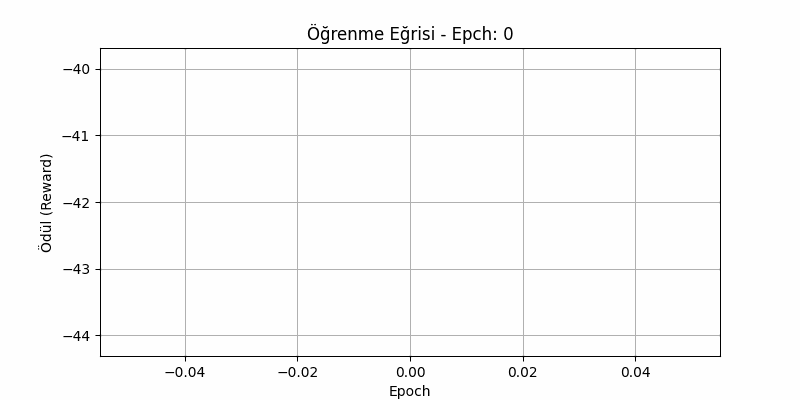

In [29]:
# q learning eğitimi ve reward/epoch gifi
env = SmartLiftEnv(num_floors=10)
q_table = np.zeros([env.state_space, env.action_space])

# atadığımız hiperparametreler
alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.999
min_epsilon = 0.01
epochs = 10000

rewards_history = []
frames_graph = []

print("ajan eğitimi başladı. bekleyin...")

for i in range(epochs):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        # epsilon-greedy stratejisi
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,2)  # keşif (exploration)
        else:
            action = np.argmax(q_table[state])  # sömürü (explotation)

        next_state, reward, done = env.step(action) 
        next_state = int(next_state)

        if done:
            next_max = 0
        else:
            next_max = np.max(q_table[next_state])
        
        # bellman denklemi
        q_table[state, action] = (1 - alpha) * q_table[state, action] + alpha * (reward + gamma * next_max)   

        state = next_state
        total_reward += reward

    rewards_history.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    # her 400 epoch'ta bir grafiğin fotoğrafını çek. gif içim
    if i % 400 == 0 or i == epochs - 1:
        plt.figure(figsize=(8,4))
        plt.plot(rewards_history, color='royalblue', alpha=0.8)
        plt.title(f"Öğrenme Eğrisi - Epch: {i}")
        plt.xlabel("Epoch")
        plt.ylabel("Ödül (Reward)")
        plt.grid(True)

        filename = f"graph_frame_{i}.png"
        plt.savefig(filename)
        frames_graph.append(imageio.imread(filename))
        plt.close()
        os.remove(filename)

# q table kaydetme
np.save("q_table_best_model.npy", q_table)
print("eğitim tamamlandı. 'q_table_best_model.npy' dosyası kaydedildi. ")

# gif bittikten sonra tekrar çıksın ve birkaç saniye beklesin.
if len(frames_graph) > 0:
    for i_ in range(7):
        frames_graph.append(frames_graph[-1])

# eğitim grafiğini gif olarak kaydetme.
imageio.mimsave('ogrenme_egrisi.gif', frames_graph, fps=4, loop=0)
print("Eğitim tamamlandı! 'ogrenme_egrisi.gif' dosyası oluşturuldu.")
display(Image(filename='ogrenme_egrisi.gif'))

C:\Users\sahin\AppData\Local\Temp\ipykernel_2052\248912497.py:37: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  return imageio.imread(buf)


Test tamamlandı! 'akilli_asansor.gif' dosyası oluşturuldu.


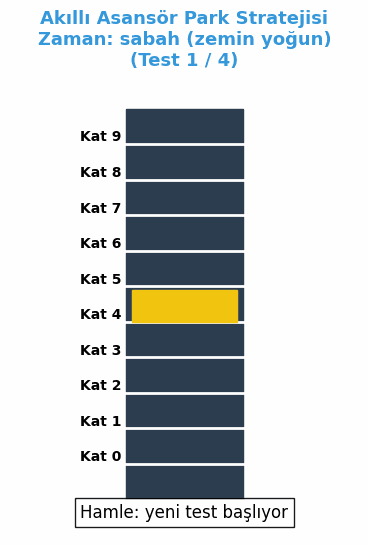

In [30]:
# asansör simülasyonu
def draw_lift_state(env, step_num, action_text="", test_num=1):
    plt.figure(figsize=(4.5, 6))

    # bina çizimi
    plt.fill_between([2, 4], -1, env.num_floors, color='#2c3e50') # asansörün hareket yerleri

    for floor in range(env.num_floors):
        plt.plot([1, 5], [floor, floor], color='white', linewidth=2, zorder=2) # kat çizgileri 
        plt.text(1.2, floor + 0.1, f"Kat {floor}", color='black', fontweight='bold')

    # asansör çizimi (sarı kabin olacak)
    plt.gca().add_patch(plt.Rectangle((2.1, env.current_floor), 1.8, 0.9, color='#f1c40f', zorder=3))

    # zaman durum ve test sayacı
    times = ["sabah (zemin yoğun)", "öğle (karışık)", "akşam (üst katlar yoğun)"]
    time_colors = ["#3498db", "#e67e22", "#8e44ad"]

    # hangi testte olduğumuzu başlığa ekleme
    plt.title(f"Akıllı Asansör Park Stratejisi\nZaman: {times[env.time_of_day]}\n(Test {test_num} / 4)", color=time_colors[env.time_of_day], fontsize=13, fontweight='bold')
    plt.text(3, -1.5, f"Hamle: {action_text}", ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.9))

    # eğer park ettiyse ve çağrı geldiyse çağrı yıldızını göster
    if env.done and env.passenger_call is not None:
        plt.plot(4.5, env.passenger_call + 0.5, marker='*', color='red', markersize=15, zorder=4)
        plt.text(4.7, env.passenger_call + 0.3, "ÇAĞRI!", color='red', fontweight='bold')

    plt.xlim(0,6)
    plt.ylim(-2, env.num_floors + 1)
    plt.axis('off')
    
    # hızlandırmak için disk yerine ram'e kaydediyoruz.
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    plt.close()
    buf.seek(0)
    return imageio.imread(buf)

frames_lift = []
global_step = 0

# 3 zaman dilimi (0: sabah, 1:öğle, 2:akşam) arka arkaya test et.
for time_of_day in[0,1,2]:
    # her zaman dilimi için 4 farklı senaryoyu test edelim
    for test_num in range(1,5):
        env.reset()
        env.time_of_day = time_of_day
        env.current_floor = 4  # asansör her testte 4. kattan yani ortadan başlasın ki nereye gideceğini görelim
    
        state = env.time_of_day * env.num_floors + env.current_floor
        done = False
        step_num = 0

        # test başlangıç ekranı.
        img = draw_lift_state(env, global_step, "yeni test başlıyor", test_num)

        for _ in range(5):  # başlangıç ekranında 5 kare bekle
            frames_lift.append(img)
        global_step +=1

        while not done and step_num < 10:
            step_num += 1
            action = np.argmax(q_table[int(state)])
            action_texts = ["park ediliyor...", "aşağı iniyor", "yukarı çıkıyor"]
            state, reward, done = env.step(action)

            img = draw_lift_state(env, global_step, action_texts[action], test_num)
            frames_lift.append(img)
            global_step +=1

            # park ettiyse son kareyi birkaç kez ekle ki gif'te okunsun
            if done:
                for _ in range(12):  # yolcu çağrıldığında ekranda 12 kare asılı kalsın görelim diye.
                    frames_lift.append(frames_lift[-1])

# asansör simülasyonunu gif olarak kaydet
imageio.mimsave("akilli_asansor.gif", frames_lift, fps=8, loop=0)
print("Test tamamlandı! 'akilli_asansor.gif' dosyası oluşturuldu.")
display(Image(filename='akilli_asansor.gif'))
